# Классификация пород кошек и собак по лицу

Используем упрощенный датасет [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) с вырезанными лицами домашних животных. Для начала загружаем датасет:

In [5]:
!wget http://www.soshnikov.com/permanent/data/petfaces.tar.gz
!tar xfz petfaces.tar.gz
!rm petfaces.tar.gz

--2026-04-24 15:15:40--  http://www.soshnikov.com/permanent/data/petfaces.tar.gz
Resolving www.soshnikov.com (www.soshnikov.com)... 79.137.227.122
Connecting to www.soshnikov.com (www.soshnikov.com)|79.137.227.122|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24483412 (23M) [application/x-tar]
Saving to: ‘petfaces.tar.gz’

petfaces.tar.gz     100%[===================>]  23.35M   259KB/s    in 93s     

2026-04-24 15:17:13 (256 KB/s) - ‘petfaces.tar.gz’ saved [24483412/24483412]



Проверка доступности GPU

In [2]:
import torch
print(torch.cuda.is_available())

True


In [8]:
!ls petfaces/

cat_Abyssinian	cat_Russian    dog_german	 dog_pug
cat_Bengal	cat_Siamese    dog_great	 dog_saint
cat_Birman	cat_Sphynx     dog_havanese	 dog_samoyed
cat_Bombay	dog_american   dog_japanese	 dog_scottish
cat_British	dog_basset     dog_keeshond	 dog_shiba
cat_Egyptian	dog_beagle     dog_leonberger	 dog_staffordshire
cat_Maine	dog_boxer      dog_miniature	 dog_wheaten
cat_Persian	dog_chihuahua  dog_newfoundland  dog_yorkshire
cat_Ragdoll	dog_english    dog_pomeranian


Для визуализации списка изображений можно использовать такую функцию:

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

def display_images(l, titles=None, fontsize=12):
    n = len(l)
    fig, ax = plt.subplots(1, n)
    for i, im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i], fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches() * n)
    plt.tight_layout()
    plt.show()



Нормализация значений выборки

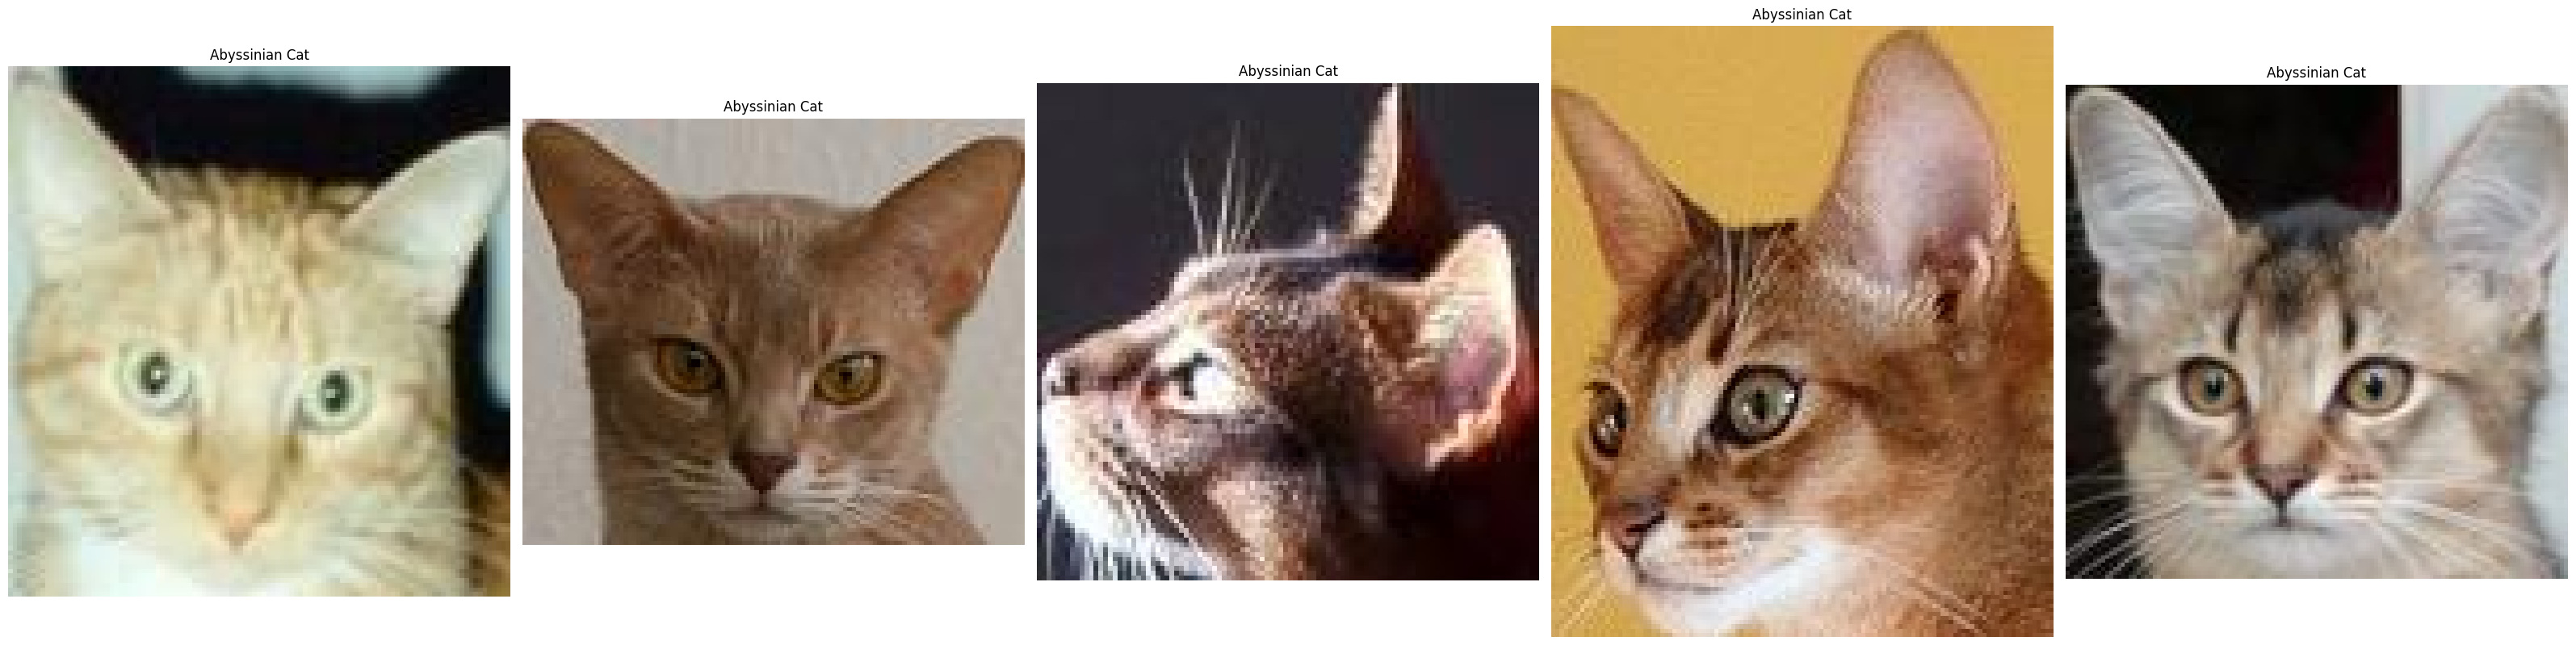

Всего пород: 35


In [7]:
sample_path = 'petfaces/cat_Abyssinian' 
sample_images = [Image.open(os.path.join(sample_path, f)) for f in os.listdir(sample_path)[:5]]
display_images(sample_images, titles=["Abyssinian Cat"]*5)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_dataset = datasets.ImageFolder('petfaces', transform=transform)

train_idx, test_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    stratify=full_dataset.targets,
    random_state=42
)

train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=32, shuffle=True)
test_loader = DataLoader(Subset(full_dataset, test_idx), batch_size=32, shuffle=False)

print(f"Всего пород: {len(full_dataset.classes)}")

Создание сверточной сети

In [8]:
class PetCNN(nn.Module):
    def __init__(self, num_classes):
        super(PetCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 64x64
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 32x32
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)  # 16x16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda") 
model = PetCNN(len(full_dataset.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Обучение в 10 эпох

In [9]:
epochs = 10
print("обучение...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Эпоха [{epoch+1}/{epochs}], Ошибка: {total_loss/len(train_loader):.4f}")

обучение...
Эпоха [1/10], Ошибка: 3.2117
Эпоха [2/10], Ошибка: 2.4263
Эпоха [3/10], Ошибка: 1.6974
Эпоха [4/10], Ошибка: 1.0916
Эпоха [5/10], Ошибка: 0.6144
Эпоха [6/10], Ошибка: 0.3423
Эпоха [7/10], Ошибка: 0.2242
Эпоха [8/10], Ошибка: 0.1737
Эпоха [9/10], Ошибка: 0.1283
Эпоха [10/10], Ошибка: 0.1082


Точность классификации пород: 42.77%
Топ 3 Точность: 66.72%
Бинарная точность (Кот/Собака): 86.94%


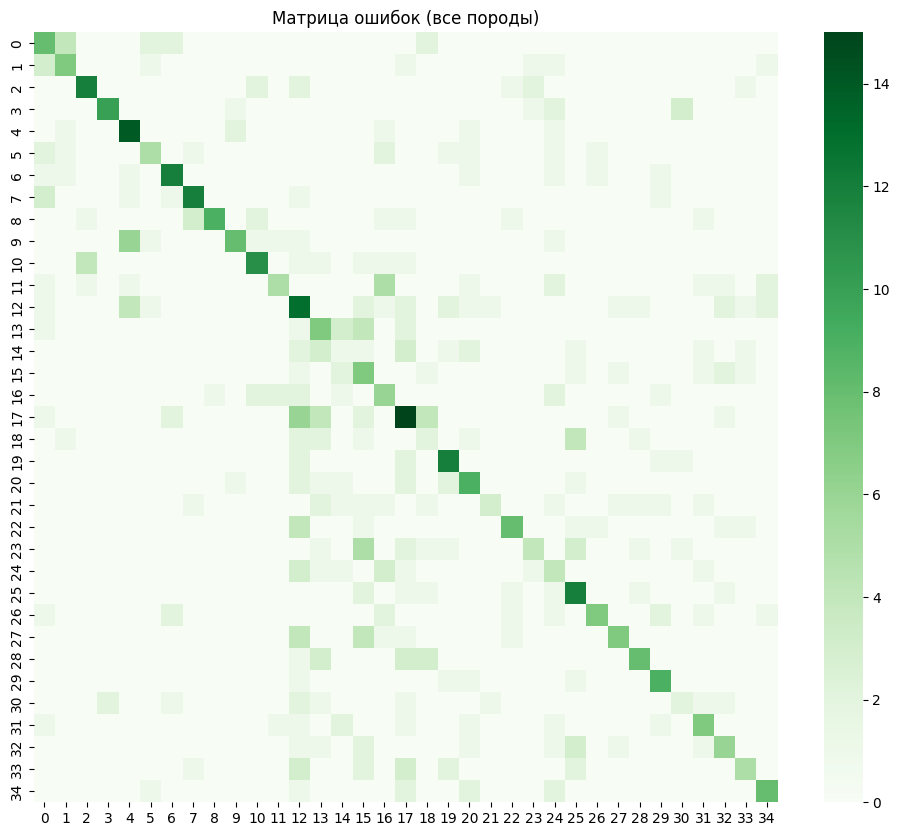

In [10]:
model.eval()
y_true = []
y_pred = []
y_probs = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs = model(imgs)
        
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(lbls.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())
 
print(f"Точность классификации пород: {accuracy_score(y_true, y_pred)*100:.2f}%")
top3_hits = 0
for i in range(len(y_true)):
    top3_preds = np.argsort(y_probs[i])[-3:]
    if y_true[i] in top3_preds:
        top3_hits += 1
print(f"Топ 3 Точность: {top3_hits/len(y_true)*100:.2f}%")

is_cat_list = [1 if "cat_" in name else 0 for name in full_dataset.classes]

bin_true = [is_cat_list[i] for i in y_true]
bin_pred = [is_cat_list[i] for i in y_pred]
print(f"Бинарная точность (Кот/Собака): {accuracy_score(bin_true, bin_pred)*100:.2f}%")

plt.figure(figsize=(12,10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=False, cmap='Greens')
plt.title('Матрица ошибок (все породы)')
plt.show()